In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

GAMES = ["dungeon", "doom", "zelda", "pokemon", "sokoban"]

# reward 체계 (5개)
REWARDS = [
    (0, "region",             "condition_0"),
    (1, "path_length",        "condition_1"),
    (2, "interactable_count", "condition_2"),
    (3, "hazard_count",       "condition_3"),
    (4, "collectable_count",  "condition_4"),
]

# ── 데이터 로드 ──────────────────────────────────────────────────────────────────
dfs = {}
for game in GAMES:
    df = pd.read_csv(f"{game}_reward_annotations.csv")
    df["game"] = game
    dfs[game] = df

all_df = pd.concat(dfs.values(), ignore_index=True)
print(f"전체 rows: {len(all_df)}")
all_df.groupby(["game", "feature_name"]).size().unstack(fill_value=0)

전체 rows: 40000


feature_name,collectable_count,hazard_count,interactable_count,path_length,region
game,,,,,
doom,1000,1000,1000,1000,1000
dungeon,4000,4000,4000,4000,4000
pokemon,1000,1000,1000,1000,1000
sokoban,1000,1000,1000,1000,1000
zelda,1000,1000,1000,1000,1000


|## Boxplot — reward별로 묶기, 각 게임 분포 비교

## Lineplot — reward별로 묶기, 게임별 KDE 분포 (같은 reward는 y-scale 통일)

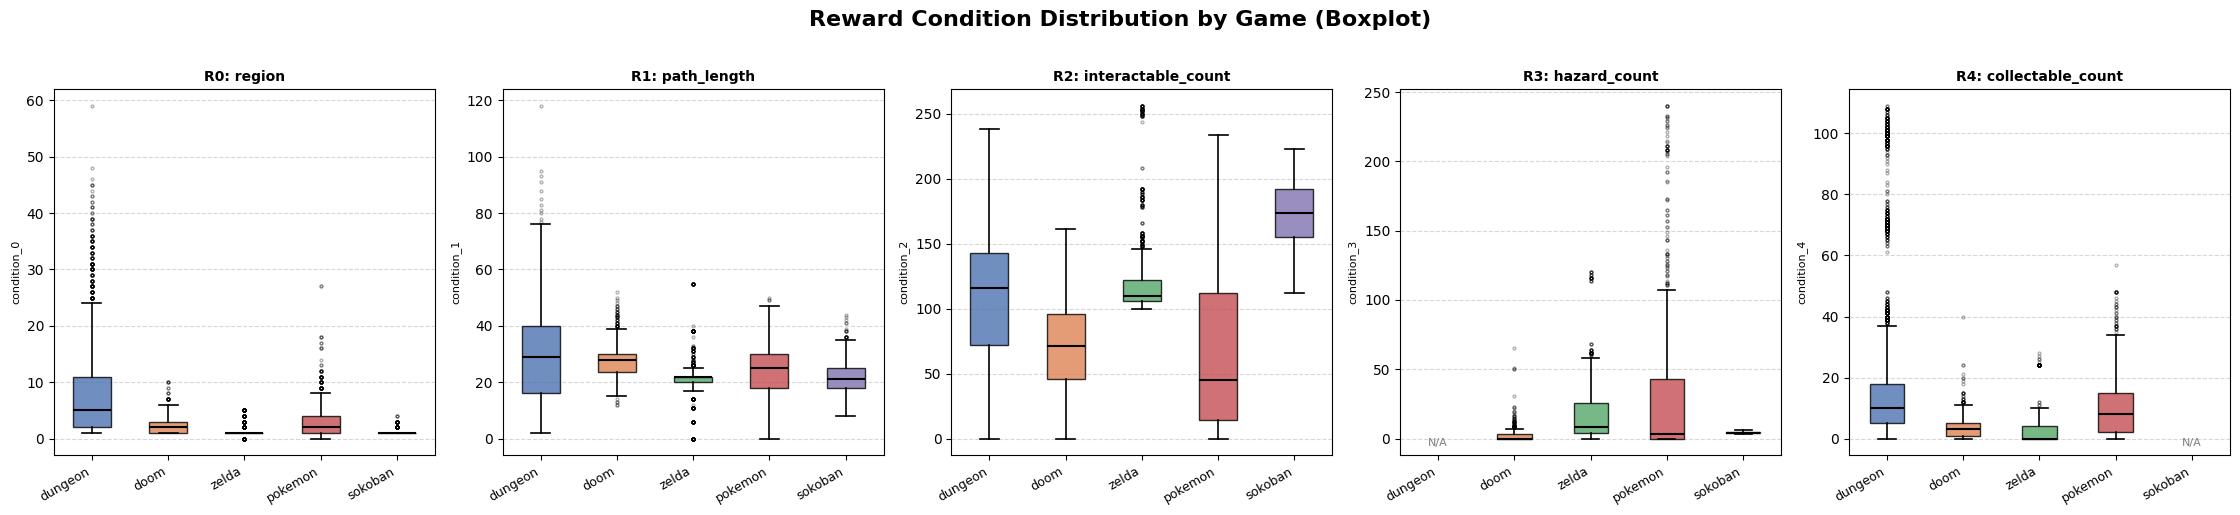

In [2]:
from matplotlib.transforms import blended_transform_factory

GAME_COLORS = {
    "dungeon": "#4C72B0",
    "doom":    "#DD8452",
    "zelda":   "#55A868",
    "pokemon": "#C44E52",
    "sokoban": "#8172B2",
}

def _is_empty(vals):
    """데이터 없음 또는 모두 0인 경우 True."""
    return len(vals) == 0 or (vals == 0).all()

n_rewards = len(REWARDS)
fig, axes = plt.subplots(1, n_rewards, figsize=(4.5 * n_rewards, 5))
fig.suptitle("Reward Condition Distribution by Game (Boxplot)", fontsize=16, fontweight="bold", y=1.02)

for ax, (r_enum, feat, cond_col) in zip(axes, REWARDS):
    sub = all_df[all_df["feature_name"] == feat]

    valid_positions, valid_data, valid_colors = [], [], []
    na_positions = []

    for idx, game in enumerate(GAMES, start=1):
        vals = pd.to_numeric(
            sub[sub["game"] == game][cond_col], errors="coerce"
        ).dropna().values
        if _is_empty(vals):
            na_positions.append(idx)
        else:
            valid_positions.append(idx)
            valid_data.append(vals)
            valid_colors.append(GAME_COLORS[game])

    if valid_data:
        bp = ax.boxplot(
            valid_data,
            positions=valid_positions,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker="o", markersize=2, alpha=0.3),
        )
        for patch, color in zip(bp["boxes"], valid_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)

    # N/A 텍스트: x는 데이터 좌표, y는 axes 하단 고정
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for idx in na_positions:
        ax.text(idx, 0.02, "N/A", ha="center", va="bottom",
                transform=trans, color="gray", fontsize=8)

    ax.set_xticks(range(1, len(GAMES) + 1))
    ax.set_xticklabels(GAMES, rotation=30, ha="right", fontsize=9)
    ax.set_xlim(0.5, len(GAMES) + 0.5)
    ax.set_title(f"R{r_enum}: {feat}", fontsize=10, fontweight="bold")
    ax.set_ylabel(cond_col, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
#plt.savefig("boxplot_rewards.png", dpi=150, bbox_inches="tight")
plt.show()

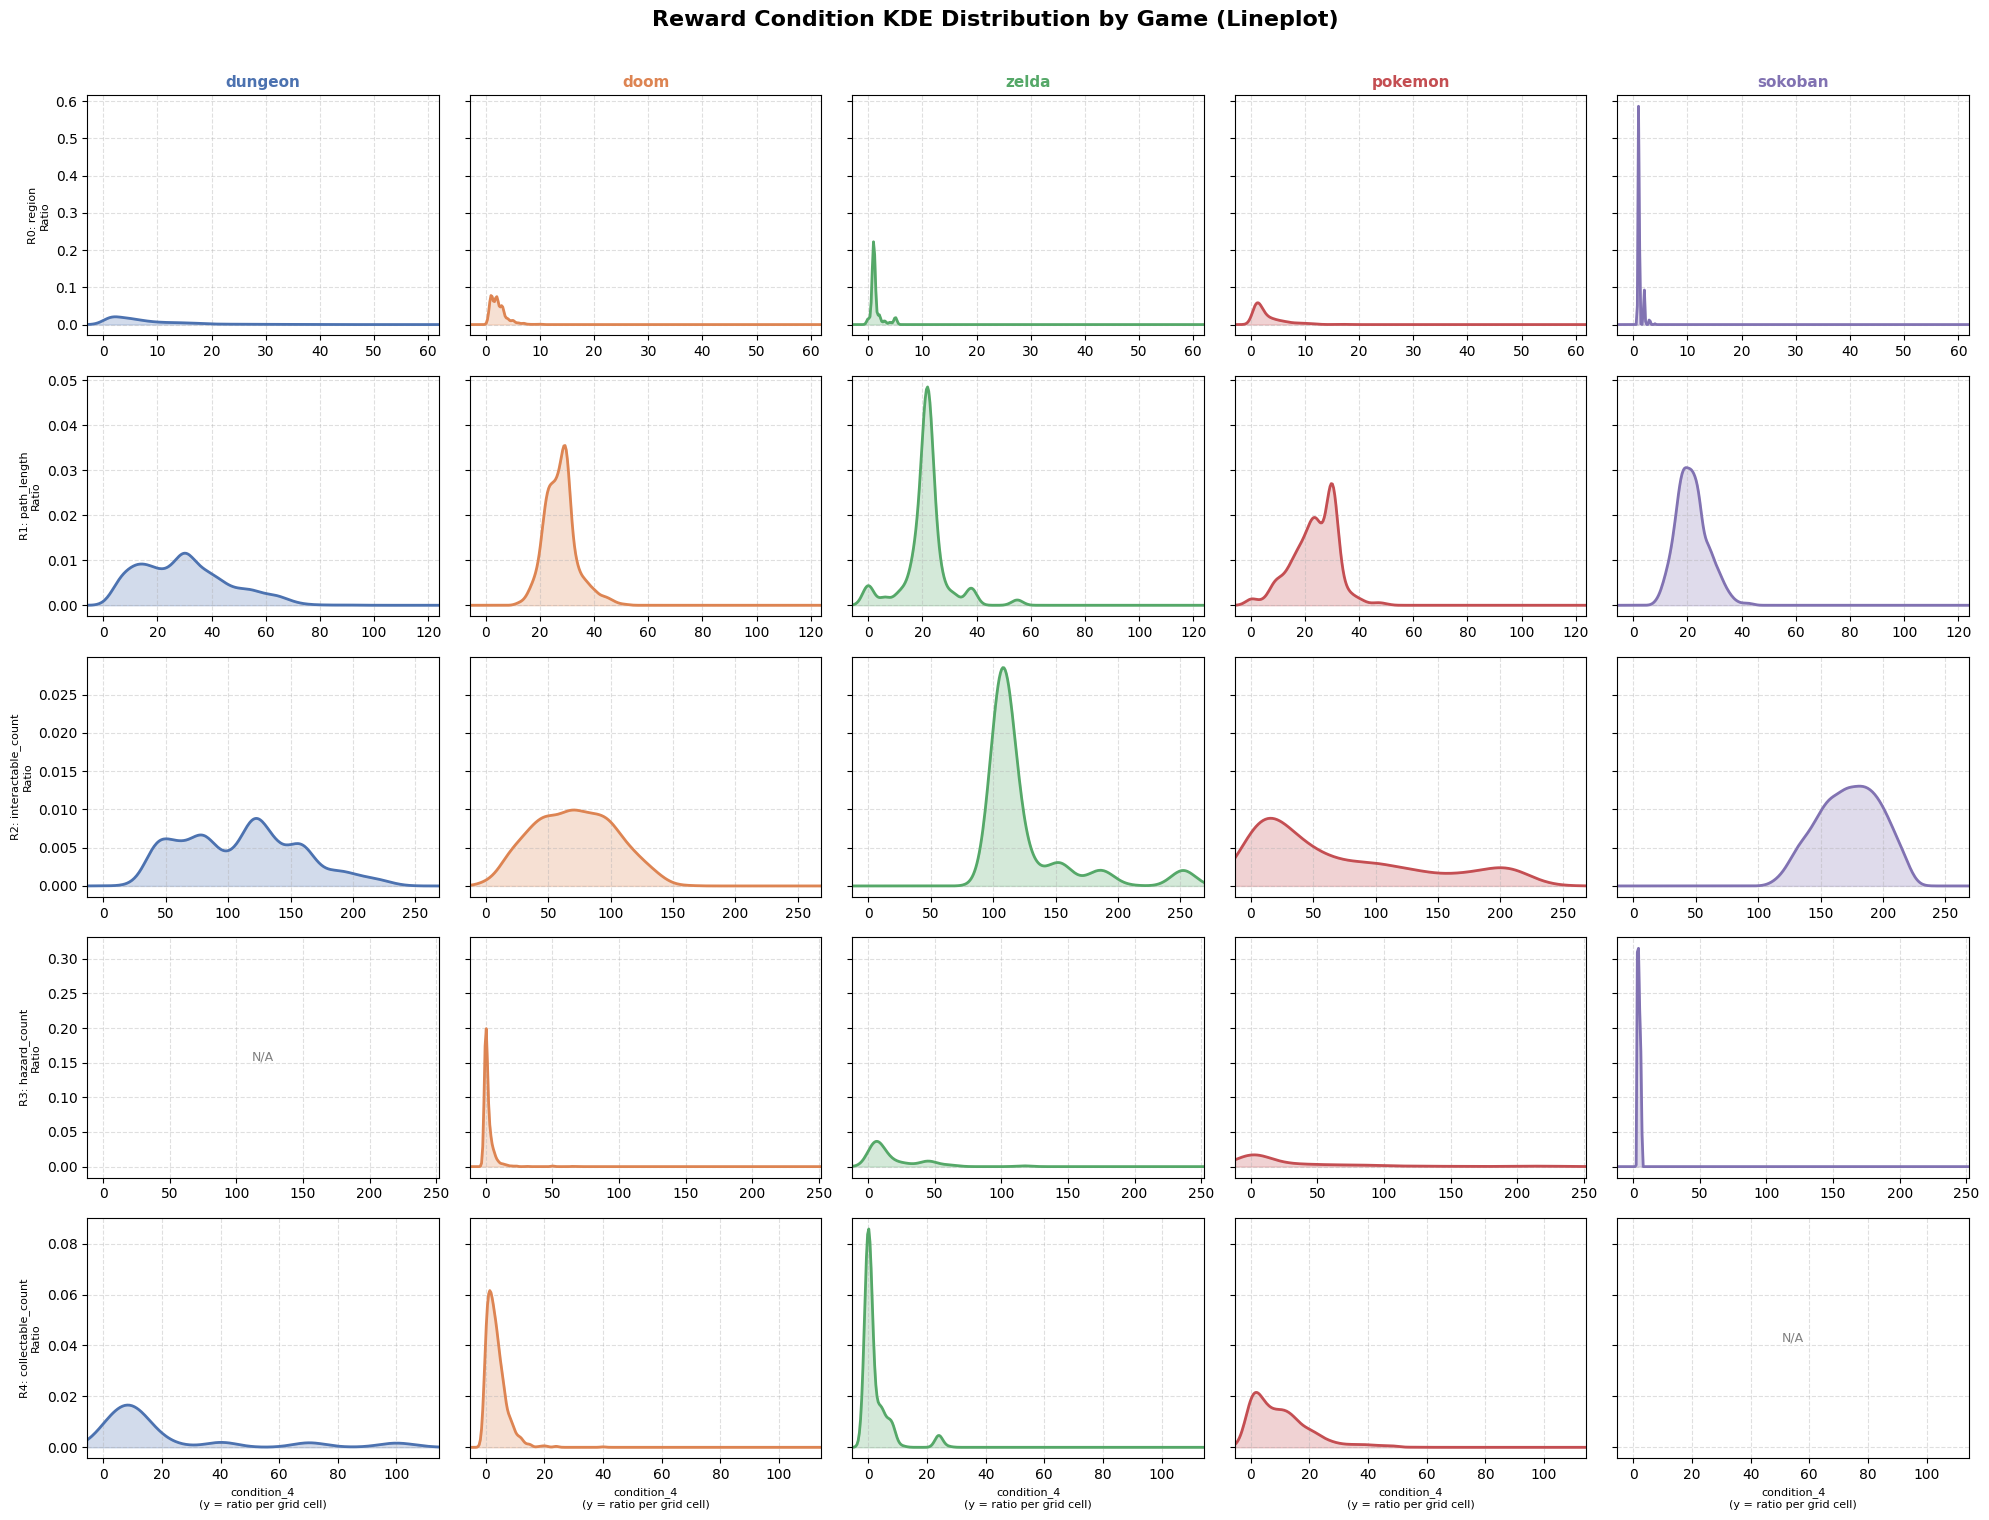

In [3]:
from scipy.stats import gaussian_kde

n_games   = len(GAMES)
n_rewards = len(REWARDS)

fig, axes = plt.subplots(
    n_rewards, n_games,
    figsize=(4 * n_games, 3.0 * n_rewards),
    sharey="row",
)
fig.suptitle("Reward Condition KDE Distribution by Game (Lineplot)", fontsize=16, fontweight="bold", y=1.01)

def _is_empty(vals):
    """데이터 없음 또는 모두 0인 경우 True."""
    return len(vals) == 0 or (vals == 0).all()

for row_i, (r_enum, feat, cond_col) in enumerate(REWARDS):
    sub = all_df[all_df["feature_name"] == feat]

    # N/A가 아닌 게임들의 값(0 포함)으로 x 범위 계산
    valid_vals = []
    for game in GAMES:
        v = pd.to_numeric(sub[sub["game"] == game][cond_col], errors="coerce").dropna().values
        if not _is_empty(v):
            valid_vals.append(v)

    if not valid_vals:
        for col_j in range(n_games):
            axes[row_i, col_j].axis("off")
        continue

    combined = np.concatenate(valid_vals)
    x_min, x_max = combined.min(), combined.max()
    x_pad = (x_max - x_min) * 0.05 if x_max > x_min else 1.0
    x_grid = np.linspace(x_min - x_pad, x_max + x_pad, 300)
    dx = x_grid[1] - x_grid[0]  # density → ratio 변환용

    for col_j, game in enumerate(GAMES):
        ax = axes[row_i, col_j]
        vals = pd.to_numeric(
            sub[sub["game"] == game][cond_col], errors="coerce"
        ).dropna().values

        if _is_empty(vals):
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=9)
            ax.set_xlim(x_min - x_pad, x_max + x_pad)
        elif vals.std() > 0:
            kde = gaussian_kde(vals, bw_method="scott")
            y = kde(x_grid) * dx  # density * dx = 각 grid cell 범위의 데이터 비율
            ax.plot(x_grid, y, color=GAME_COLORS[game], linewidth=2)
            ax.fill_between(x_grid, y, alpha=0.25, color=GAME_COLORS[game])
            ax.set_xlim(x_min - x_pad, x_max + x_pad)
        else:
            ax.axvline(vals.mean(), color=GAME_COLORS[game], linewidth=2)
            ax.set_xlim(x_min - x_pad, x_max + x_pad)

        ax.grid(axis="both", linestyle="--", alpha=0.4)
        if col_j == 0:
            ax.set_ylabel(f"R{r_enum}: {feat}\nRatio", fontsize=8)
        if row_i == 0:
            ax.set_title(game, fontsize=11, fontweight="bold", color=GAME_COLORS[game])
        if row_i == n_rewards - 1:
            ax.set_xlabel(f"{cond_col}\n(y = ratio per grid cell)", fontsize=8)

plt.tight_layout()
#plt.savefig("lineplot_rewards_kde.png", dpi=150, bbox_inches="tight")
plt.show()

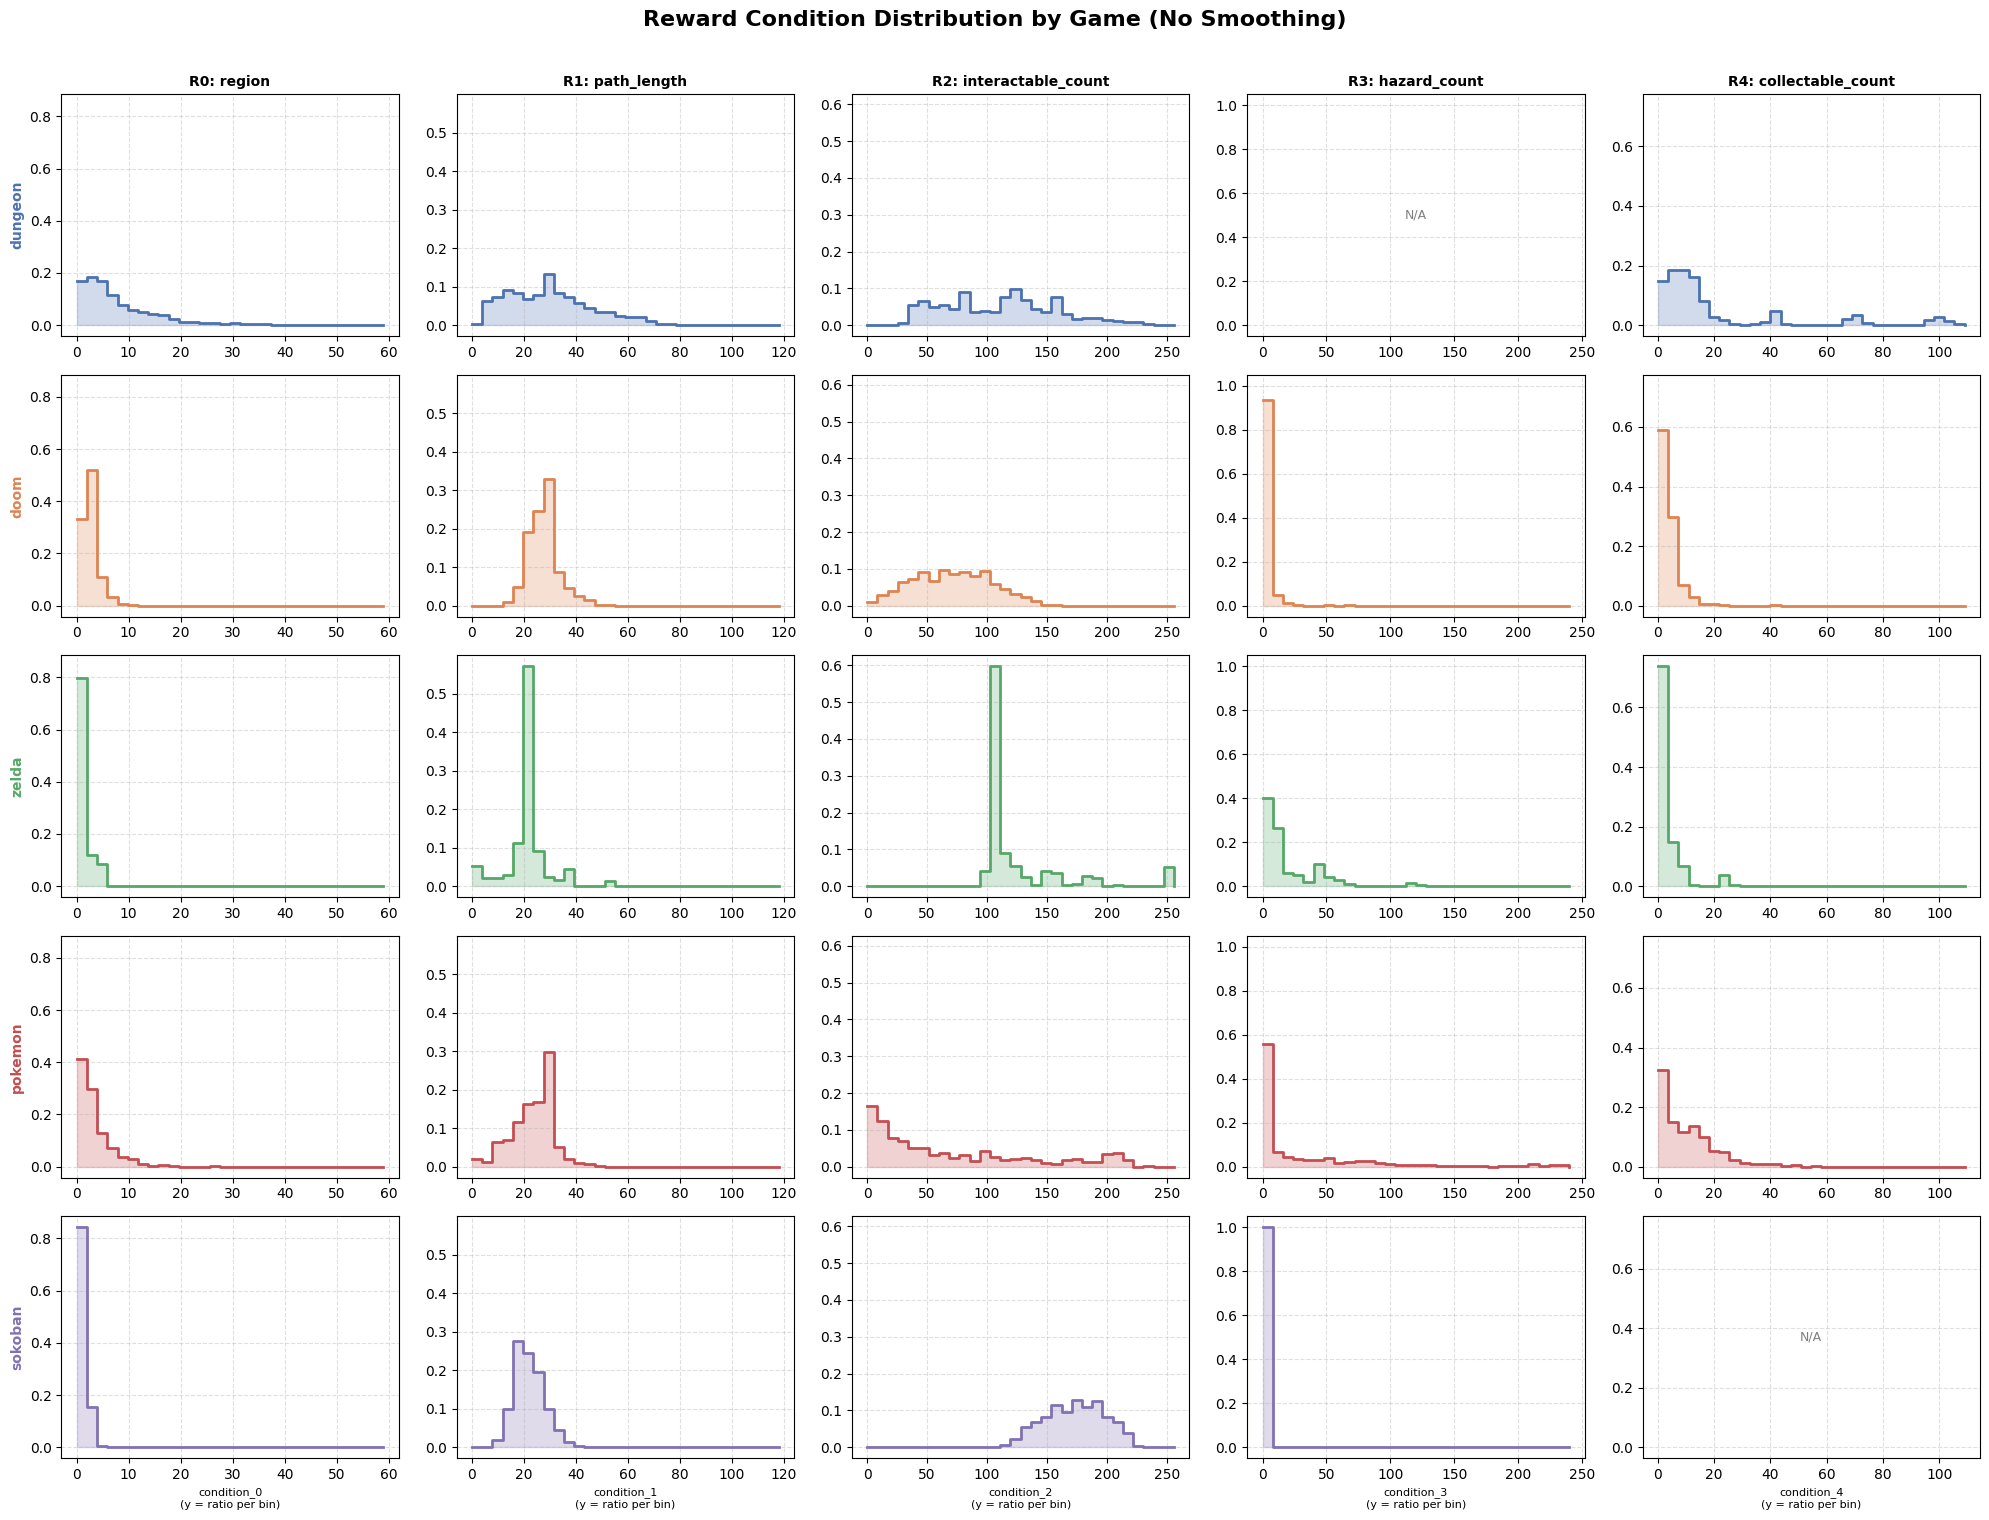

In [4]:
# Lineplot (smoothing 없음) — 행=game, 열=reward, 같은 reward(열)는 y-scale 통일
n_games   = len(GAMES)
n_rewards = len(REWARDS)

fig, axes = plt.subplots(
    n_games, n_rewards,
    figsize=(4 * n_rewards, 3.0 * n_games),
    sharey="col",
)
fig.suptitle("Reward Condition Distribution by Game (No Smoothing)", fontsize=16, fontweight="bold", y=1.01)

N_BINS = 30

def _is_empty(vals):
    """데이터 없음 또는 모두 0인 경우 True."""
    return len(vals) == 0 or (vals == 0).all()

# reward별 x 범위: N/A가 아닌 게임들의 값(0 포함)으로 계산
reward_ranges = {}
for r_enum, feat, cond_col in REWARDS:
    sub = all_df[all_df["feature_name"] == feat]
    valid_vals = []
    for game in GAMES:
        v = pd.to_numeric(sub[sub["game"] == game][cond_col], errors="coerce").dropna().values
        if not _is_empty(v):
            valid_vals.append(v)
    if valid_vals:
        combined = np.concatenate(valid_vals)
        vmin, vmax = combined.min(), combined.max()
        reward_ranges[feat] = (vmin, vmax) if vmax > vmin else (vmin - 1, vmax + 1)
    else:
        reward_ranges[feat] = (0.0, 1.0)

for col_j, (r_enum, feat, cond_col) in enumerate(REWARDS):
    x_min, x_max = reward_ranges[feat]
    x_pad = (x_max - x_min) * 0.05 if x_max > x_min else 1.0
    bins  = np.linspace(x_min, x_max, N_BINS + 1)

    sub = all_df[all_df["feature_name"] == feat]

    for row_i, game in enumerate(GAMES):
        ax = axes[row_i, col_j]
        vals = pd.to_numeric(
            sub[sub["game"] == game][cond_col], errors="coerce"
        ).dropna().values

        if _is_empty(vals):
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=9)
            ax.set_xlim(x_min - x_pad, x_max + x_pad)
        else:
            counts, edges = np.histogram(vals, bins=bins, density=False)
            ratio = counts / len(vals)  # 전체 데이터 중 각 bin의 비율 (0값 포함)
            x_step = np.append(edges[:-1], edges[-1])
            y_step = np.append(ratio, 0)
            ax.step(x_step, y_step, where="post",
                    color=GAME_COLORS[game], linewidth=2)
            ax.fill_between(x_step, y_step, step="post",
                            alpha=0.25, color=GAME_COLORS[game])
            ax.set_xlim(x_min - x_pad, x_max + x_pad)

        ax.grid(axis="both", linestyle="--", alpha=0.4)
        if col_j == 0:
            ax.set_ylabel(game, fontsize=10, fontweight="bold", color=GAME_COLORS[game])
        if row_i == 0:
            ax.set_title(f"R{r_enum}: {feat}", fontsize=10, fontweight="bold")
        if row_i == n_games - 1:
            ax.set_xlabel(f"{cond_col}\n(y = ratio per bin)", fontsize=8)

plt.tight_layout()
plt.show()